In [2]:
import os
import json
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Setup styling
plt.style.use('dark_background')
sns.set_palette("viridis")

# Setup output dir
output_dir = "../../data/model_analysis/v10_v18_comparison/"
os.makedirs(output_dir, exist_ok=True)

# Load data
data_path = "../../data/ranking_data_upstox_1h_v3_3y.csv"
print(f"Loading dataset: {data_path}")
df = pd.read_csv(data_path)
df['Date'] = pd.to_datetime(df['Date'])

# Filter for 2026 Out of Sample
df_oos = df[df['Date'] >= '2026-01-01'].copy()
print(f"OOS Dataset Size: {len(df_oos)} rows")

# Load features from v10 metadata
with open("../../models/v10_native_1h/metadata.json", "r") as f:
    v10_meta = json.load(f)
features = v10_meta["features"]

X_oos = df_oos[features]

# Load models
v10_long = xgb.Booster()
v10_long.load_model("../../models/v10_native_1h/xgb_long_model.json")
v10_short = xgb.Booster()
v10_short.load_model("../../models/v10_native_1h/xgb_short_model.json")

v18_long = xgb.Booster()
v18_long.load_model("../../models/v18_random_forest_1h/xgb_long_model.json")
v18_short = xgb.Booster()
v18_short.load_model("../../models/v18_random_forest_1h/xgb_short_model.json")

# Create DMatrix
dtest = xgb.DMatrix(X_oos)

# Generate Predictions
print("Generating predictions...")
df_oos['v10_long_score'] = v10_long.predict(dtest)
df_oos['v10_short_score'] = v10_short.predict(dtest)
df_oos['v18_long_prob'] = v18_long.predict(dtest)
df_oos['v18_short_prob'] = v18_short.predict(dtest)

print("Setup complete.")

Loading dataset: ../../data/ranking_data_upstox_1h_v3_3y.csv


FileNotFoundError: [Errno 2] No such file or directory: '../../data/ranking_data_upstox_1h_v3_3y.csv'

In [3]:
import os
print(os.getcwd())

C:\Users\loq\Desktop\Trading\finalgo


In [4]:
import os
import json
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Setup styling
plt.style.use('dark_background')
sns.set_palette("viridis")

# Setup output dir
output_dir = "data/model_analysis/v10_v18_comparison/"
os.makedirs(output_dir, exist_ok=True)

# Load data
data_path = "data/ranking_data_upstox_1h_v3_3y.csv"
print(f"Loading dataset: {data_path}")
df = pd.read_csv(data_path)
df['Date'] = pd.to_datetime(df['Date'])

# Filter for 2026 Out of Sample
df_oos = df[df['Date'] >= '2026-01-01'].copy()
print(f"OOS Dataset Size: {len(df_oos)} rows")

# Load features from v10 metadata
with open("models/v10_native_1h/metadata.json", "r") as f:
    v10_meta = json.load(f)
features = v10_meta["features"]

X_oos = df_oos[features]

# Load models
v10_long = xgb.Booster()
v10_long.load_model("models/v10_native_1h/xgb_long_model.json")
v10_short = xgb.Booster()
v10_short.load_model("models/v10_native_1h/xgb_short_model.json")

v18_long = xgb.Booster()
v18_long.load_model("models/v18_random_forest_1h/xgb_long_model.json")
v18_short = xgb.Booster()
v18_short.load_model("models/v18_random_forest_1h/xgb_short_model.json")

# Create DMatrix
dtest = xgb.DMatrix(X_oos)

# Generate Predictions
print("Generating predictions...")
df_oos['v10_long_score'] = v10_long.predict(dtest)
df_oos['v10_short_score'] = v10_short.predict(dtest)
df_oos['v18_long_prob'] = v18_long.predict(dtest)
df_oos['v18_short_prob'] = v18_short.predict(dtest)

print("Setup complete.")

Loading dataset: data/ranking_data_upstox_1h_v3_3y.csv


KeyError: 'Date'

In [5]:
import pandas as pd
df = pd.read_csv("data/ranking_data_upstox_1h_v3_3y.csv", nrows=5)
print(df.columns.tolist())

['Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'Log_Return', 'HL_Range', 'OC_Range', 'Dist_SMA_6', 'Dist_SMA_12', 'Dist_SMA_50', 'Dist_EMA_12', 'Dist_EMA_24', 'Dist_HMA_12', 'RSI_14', 'ROC_12', 'MOM_12_pct', 'CCI_20', 'WPR_14', 'TRIX_15', 'PPO', 'PPO_Signal', 'PPO_Hist', 'Dist_DPO_20', 'Ultimate_Osc', 'PercentB', 'Dist_BB_Upper', 'Dist_BB_Lower', 'BB_Width', 'Dist_Donchian_Upper', 'Dist_Donchian_Lower', 'Donchian_Width', 'Dist_Keltner_Upper', 'Dist_Keltner_Lower', 'Keltner_Width', 'OBV_Dist', 'CMF_20', 'Volume_Change', 'Volume_Zscore', 'PVO', 'Stoch_K', 'Stoch_D', 'Elder_Bull', 'Elder_Bear', 'Vortex_Plus', 'Vortex_Minus', 'Price_Zscore', 'Rolling_Skew', 'Rolling_Kurt', 'Price_Accel', 'Hour', 'DayOfWeek', 'Dollar_Volume', 'RVOL', 'Dist_52W_High', 'Dist_52W_Low', 'Return_lag1', 'RSI_lag1', 'Volume_Zscore_lag1', 'OC_Range_lag1', 'Return_lag2', 'RSI_lag2', 'Volume_Zscore_lag2', 'OC_Range_lag2', 'Return_lag3', 'RSI_lag3', 'Volume_Zscore_lag3', 'OC_Range_lag3', 'Up_Streak', 'Down_Strea

In [6]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Filter for 2026 Out of Sample
df_oos = df[df['DateTime'] >= '2026-01-01'].copy()
print(f"OOS Dataset Size: {len(df_oos)} rows")

X_oos = df_oos[features]

print("Generating predictions...")
df_oos['v10_long_score'] = v10_long.predict(xgb.DMatrix(X_oos))
df_oos['v10_short_score'] = v10_short.predict(xgb.DMatrix(X_oos))
df_oos['v18_long_prob'] = v18_long.predict(xgb.DMatrix(X_oos))
df_oos['v18_short_prob'] = v18_short.predict(xgb.DMatrix(X_oos))

print("Inference complete.")

OOS Dataset Size: 0 rows


NameError: name 'features' is not defined

In [7]:
import os
import json
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Setup styling
plt.style.use('dark_background')
sns.set_palette("viridis")

# Setup output dir
output_dir = "data/model_analysis/v10_v18_comparison/"
os.makedirs(output_dir, exist_ok=True)

# Load data
data_path = "data/ranking_data_upstox_1h_v3_3y.csv"
print(f"Loading dataset: {data_path}")
df = pd.read_csv(data_path)
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Filter for 2026 Out of Sample
df_oos = df[df['DateTime'] >= '2026-01-01'].copy()
print(f"OOS Dataset Size: {len(df_oos)} rows")

# Load features from v10 metadata
with open("models/v10_native_1h/metadata.json", "r") as f:
    v10_meta = json.load(f)
features = v10_meta["features"]

X_oos = df_oos[features]

# Load models
v10_long = xgb.Booster()
v10_long.load_model("models/v10_native_1h/xgb_long_model.json")
v10_short = xgb.Booster()
v10_short.load_model("models/v10_native_1h/xgb_short_model.json")

v18_long = xgb.Booster()
v18_long.load_model("models/v18_random_forest_1h/xgb_long_model.json")
v18_short = xgb.Booster()
v18_short.load_model("models/v18_random_forest_1h/xgb_short_model.json")

# Create DMatrix
dtest = xgb.DMatrix(X_oos)

# Generate Predictions
print("Generating predictions...")
df_oos['v10_long_score'] = v10_long.predict(dtest)
df_oos['v10_short_score'] = v10_short.predict(dtest)
df_oos['v18_long_prob'] = v18_long.predict(dtest)
df_oos['v18_short_prob'] = v18_short.predict(dtest)

print("Setup complete.")

Loading dataset: data/ranking_data_upstox_1h_v3_3y.csv


OOS Dataset Size: 89424 rows


Generating predictions...
Setup complete.


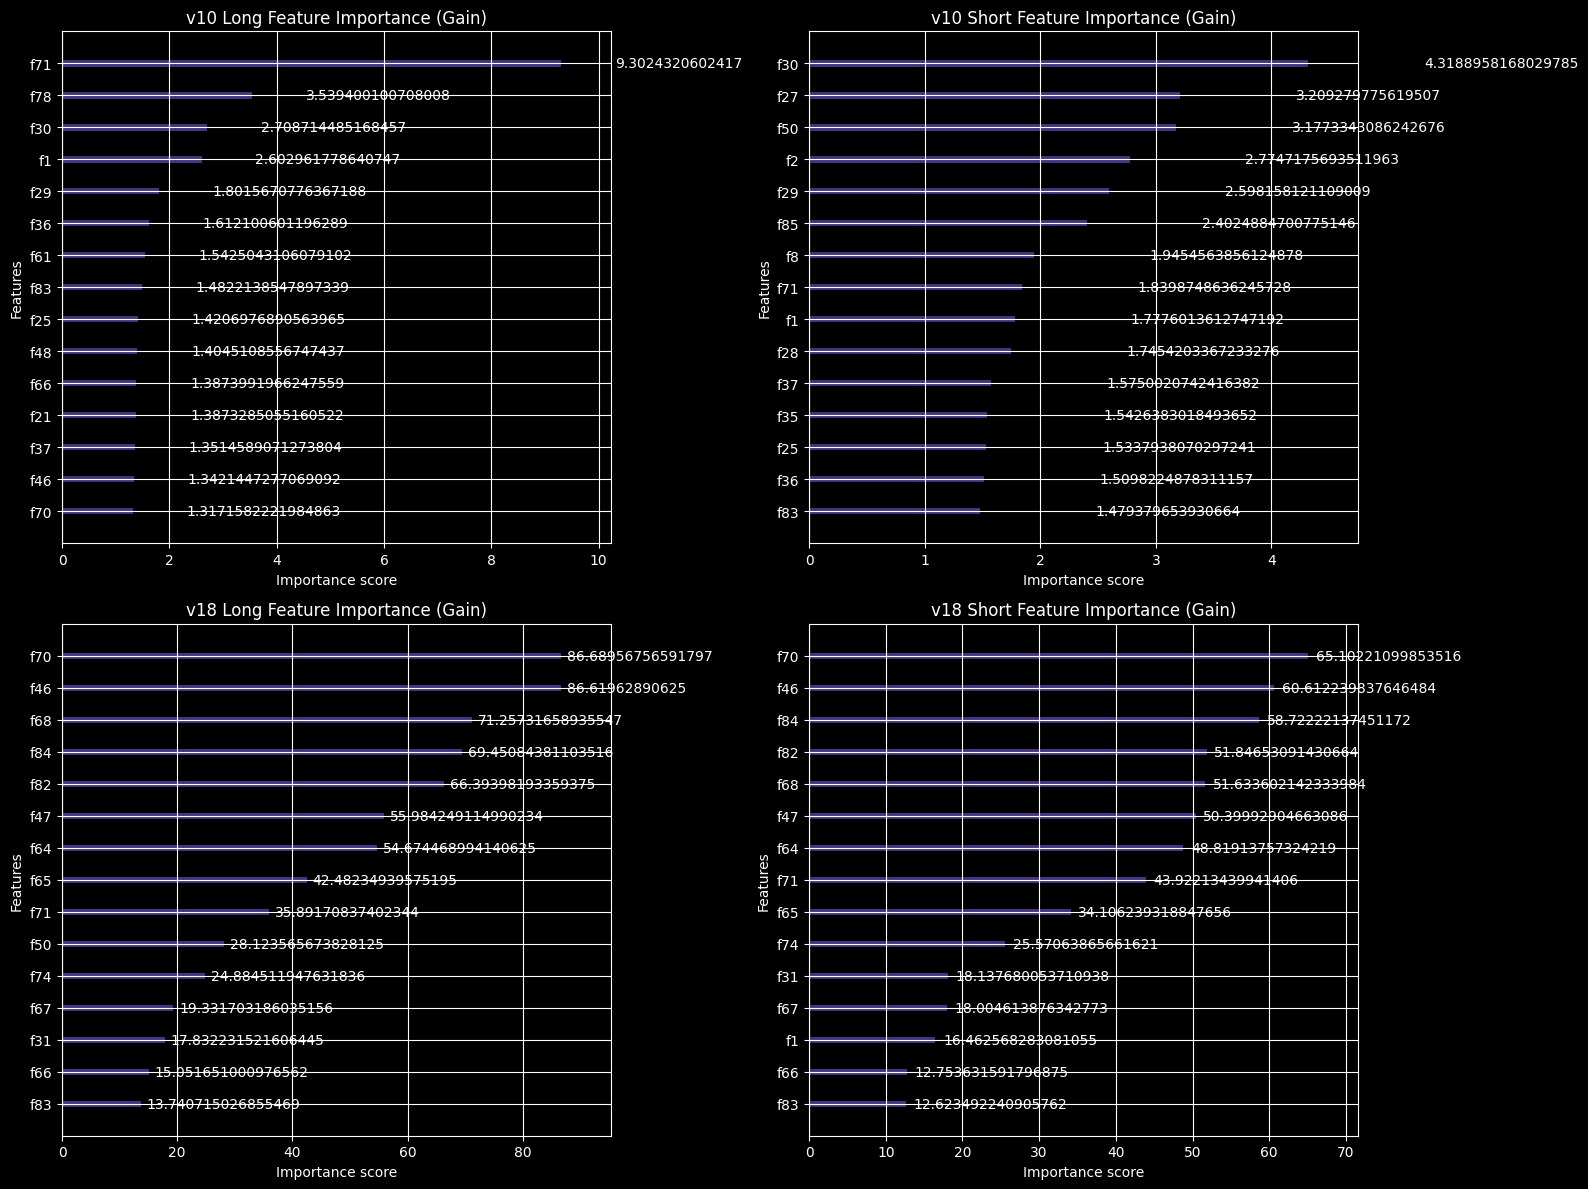

In [8]:
# Feature Importance (Gain)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

xgb.plot_importance(v10_long, max_num_features=15, ax=axes[0,0], importance_type="gain", title="v10 Long Feature Importance (Gain)")
xgb.plot_importance(v10_short, max_num_features=15, ax=axes[0,1], importance_type="gain", title="v10 Short Feature Importance (Gain)")
xgb.plot_importance(v18_long, max_num_features=15, ax=axes[1,0], importance_type="gain", title="v18 Long Feature Importance (Gain)")
xgb.plot_importance(v18_short, max_num_features=15, ax=axes[1,1], importance_type="gain", title="v18 Short Feature Importance (Gain)")

plt.tight_layout()
plt.savefig(f"{output_dir}/feature_importance.png", dpi=150)
plt.show()

Computing SHAP values (10k sample)...


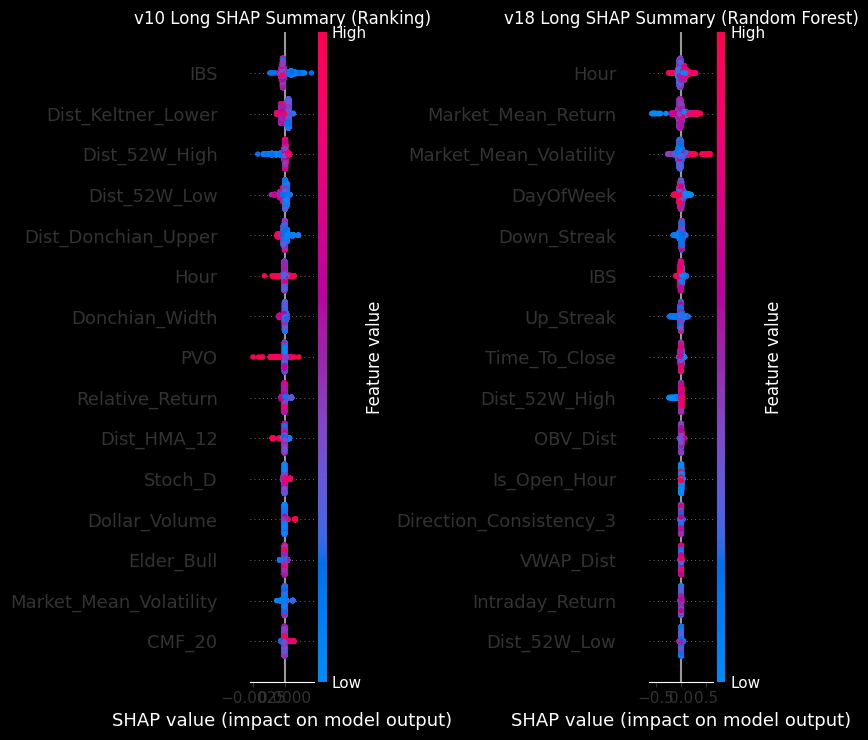

In [9]:
# Compute SHAP Values on a 10,000 row sub-sample for speed
print("Computing SHAP values (10k sample)...")
X_sample = X_oos.sample(n=10000, random_state=42)

explainer_v10 = shap.TreeExplainer(v10_long)
shap_v10 = explainer_v10.shap_values(X_sample)

explainer_v18 = shap.TreeExplainer(v18_long)
shap_v18 = explainer_v18.shap_values(X_sample)

# Plot SHAP
fig = plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.title("v10 Long SHAP Summary (Ranking)")
shap.summary_plot(shap_v10, X_sample, plot_type="dot", show=False, max_display=15)

plt.subplot(1, 2, 2)
plt.title("v18 Long SHAP Summary (Random Forest)")
shap.summary_plot(shap_v18, X_sample, plot_type="dot", show=False, max_display=15)

plt.tight_layout()
plt.savefig(f"{output_dir}/shap_summary.png", dpi=150)
plt.show()

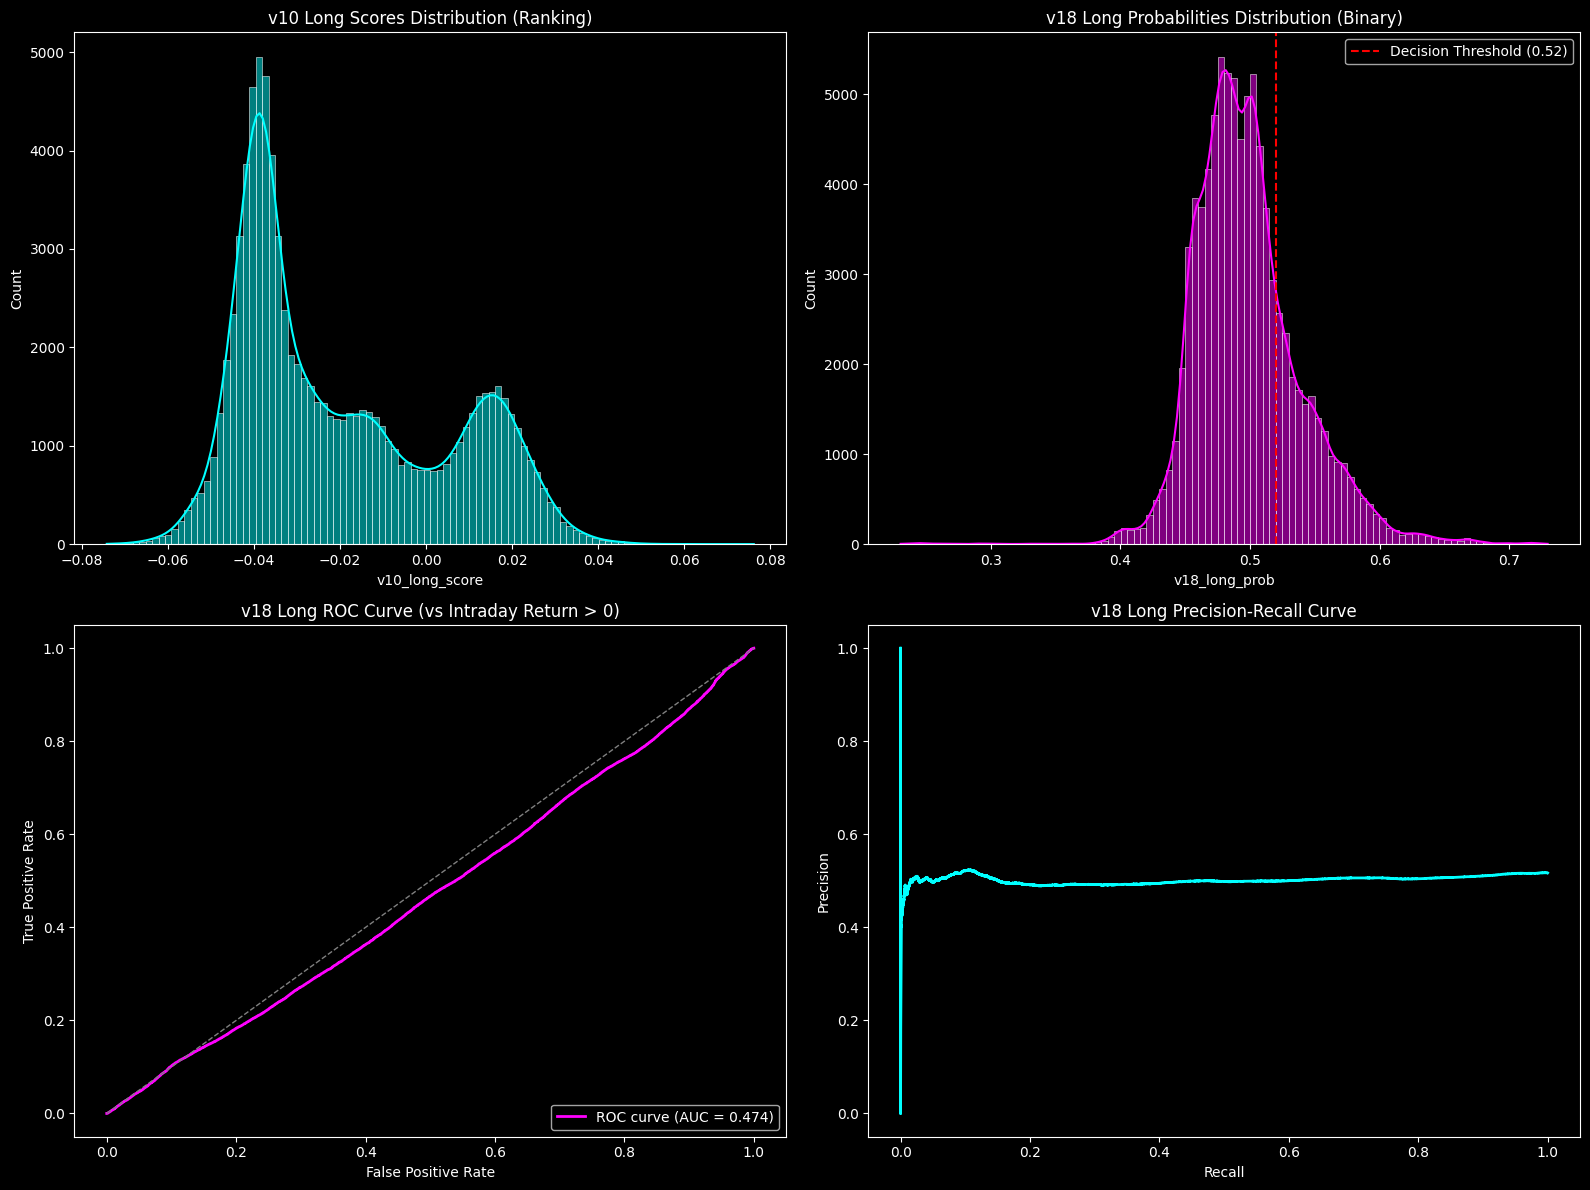

In [10]:
# Prediction Distributions & ROC
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# v10 Distribution
sns.histplot(df_oos['v10_long_score'], bins=100, ax=axes[0,0], color='cyan', kde=True)
axes[0,0].set_title("v10 Long Scores Distribution (Ranking)")

# v18 Distribution
sns.histplot(df_oos['v18_long_prob'], bins=100, ax=axes[0,1], color='magenta', kde=True)
axes[0,1].set_title("v18 Long Probabilities Distribution (Binary)")
axes[0,1].axvline(0.52, color='red', linestyle='--', label="Decision Threshold (0.52)")
axes[0,1].legend()

# ROC for v18 (Assuming we can create a proxy binary target for > 0 return)
y_binary_long = (df_oos['Intraday_Return'] > 0).astype(int)
fpr, tpr, _ = roc_curve(y_binary_long, df_oos['v18_long_prob'])
roc_auc = auc(fpr, tpr)

axes[1,0].plot(fpr, tpr, color='magenta', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1,0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].set_title('v18 Long ROC Curve (vs Intraday Return > 0)')
axes[1,0].legend(loc="lower right")

# Precision-Recall for v18
precision, recall, _ = precision_recall_curve(y_binary_long, df_oos['v18_long_prob'])
axes[1,1].plot(recall, precision, color='cyan', lw=2)
axes[1,1].set_xlabel('Recall')
axes[1,1].set_ylabel('Precision')
axes[1,1].set_title('v18 Long Precision-Recall Curve')

plt.tight_layout()
plt.savefig(f"{output_dir}/distributions_roc.png", dpi=150)
plt.show()

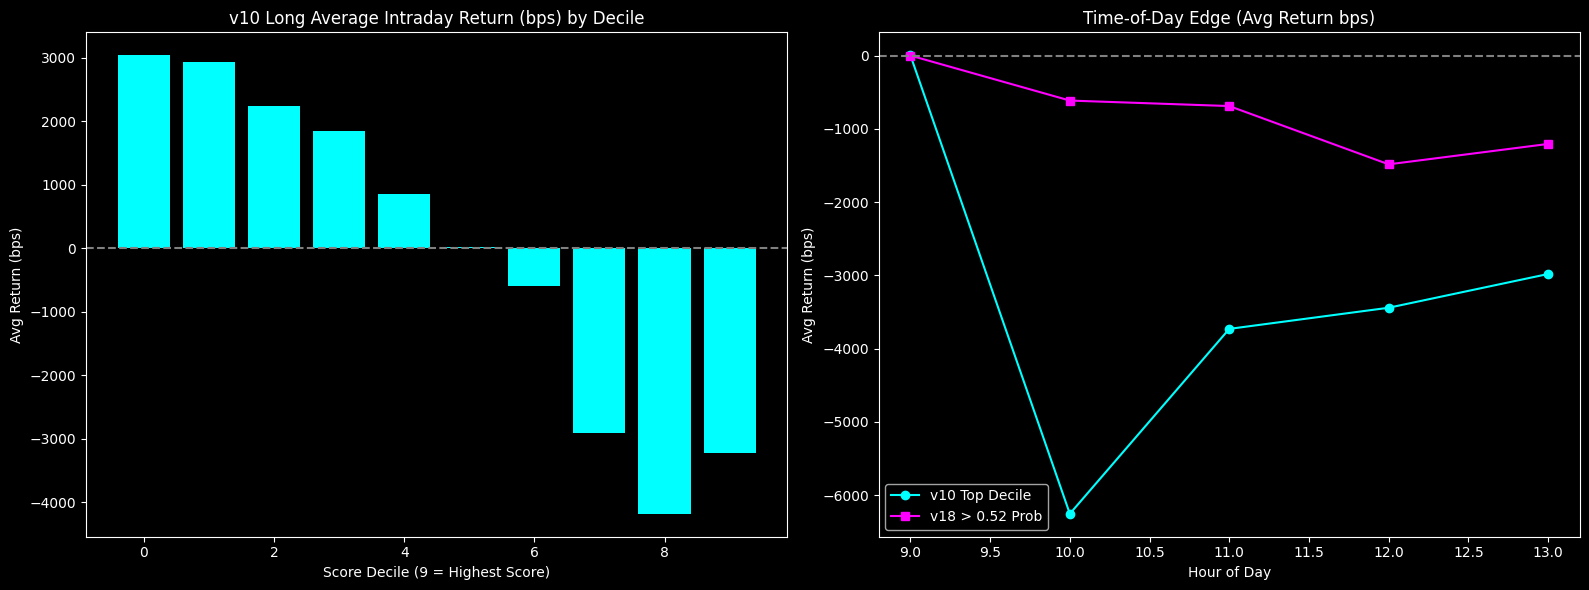

In [11]:
# Quantile / Bucket Returns for v10
df_oos['v10_long_quantile'] = pd.qcut(df_oos['v10_long_score'], q=10, labels=False, duplicates='drop')
bucket_returns = df_oos.groupby('v10_long_quantile')['Intraday_Return'].mean() * 10000 # in bps

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(bucket_returns.index, bucket_returns.values, color='cyan')
axes[0].set_title('v10 Long Average Intraday Return (bps) by Decile')
axes[0].set_xlabel('Score Decile (9 = Highest Score)')
axes[0].set_ylabel('Avg Return (bps)')
axes[0].axhline(0, color='gray', linestyle='--')

# ToD Edge Metrics for Top Decile vs v18 > 0.52
top_decile = df_oos[df_oos['v10_long_quantile'] == 9]
v18_pass = df_oos[df_oos['v18_long_prob'] > 0.52]

tod_v10 = top_decile.groupby('Hour')['Intraday_Return'].mean() * 10000
tod_v18 = v18_pass.groupby('Hour')['Intraday_Return'].mean() * 10000

axes[1].plot(tod_v10.index, tod_v10.values, marker='o', color='cyan', label='v10 Top Decile')
axes[1].plot(tod_v18.index, tod_v18.values, marker='s', color='magenta', label='v18 > 0.52 Prob')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Time-of-Day Edge (Avg Return bps)')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg Return (bps)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{output_dir}/bucket_returns.png", dpi=150)
plt.show()

# Compute simple summary metrics
summary_metrics = {
    "v10_top_decile_bps": float(tod_v10.mean()),
    "v18_pass_bps": float(tod_v18.mean()),
    "v18_pass_count": len(v18_pass),
    "v18_win_rate": float((v18_pass['Intraday_Return'] > 0).mean())
}

with open(f"{output_dir}/summary_metrics.json", "w") as f:
    json.dump(summary_metrics, f, indent=4)


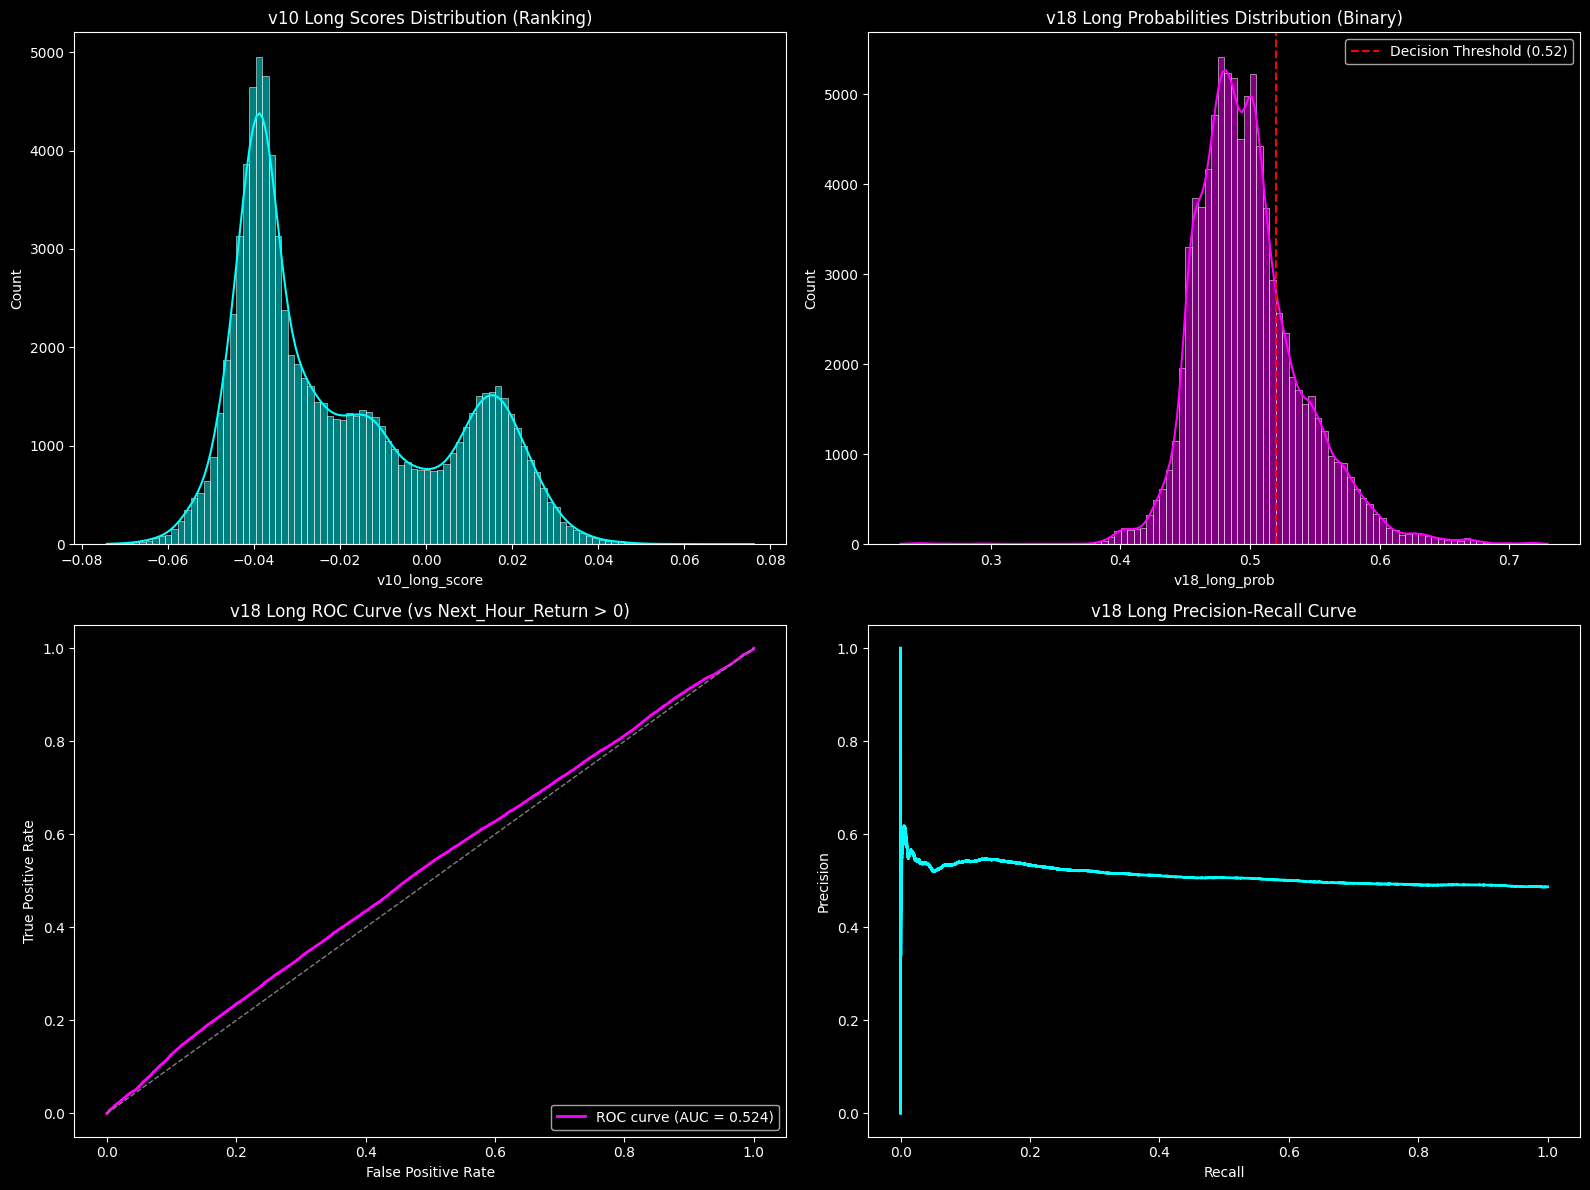

In [12]:
# FIXED Prediction Distributions & ROC
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# v10 Distribution
sns.histplot(df_oos['v10_long_score'], bins=100, ax=axes[0,0], color='cyan', kde=True)
axes[0,0].set_title("v10 Long Scores Distribution (Ranking)")

# v18 Distribution
sns.histplot(df_oos['v18_long_prob'], bins=100, ax=axes[0,1], color='magenta', kde=True)
axes[0,1].set_title("v18 Long Probabilities Distribution (Binary)")
axes[0,1].axvline(0.52, color='red', linestyle='--', label="Decision Threshold (0.52)")
axes[0,1].legend()

# ROC for v18 (Using Next_Hour_Return)
y_binary_long = (df_oos['Next_Hour_Return'] > 0).astype(int)
fpr, tpr, _ = roc_curve(y_binary_long, df_oos['v18_long_prob'])
roc_auc = auc(fpr, tpr)

axes[1,0].plot(fpr, tpr, color='magenta', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1,0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].set_title('v18 Long ROC Curve (vs Next_Hour_Return > 0)')
axes[1,0].legend(loc="lower right")

# Precision-Recall for v18
precision, recall, _ = precision_recall_curve(y_binary_long, df_oos['v18_long_prob'])
axes[1,1].plot(recall, precision, color='cyan', lw=2)
axes[1,1].set_xlabel('Recall')
axes[1,1].set_ylabel('Precision')
axes[1,1].set_title('v18 Long Precision-Recall Curve')

plt.tight_layout()
plt.savefig(f"{output_dir}/distributions_roc.png", dpi=150)
plt.show()

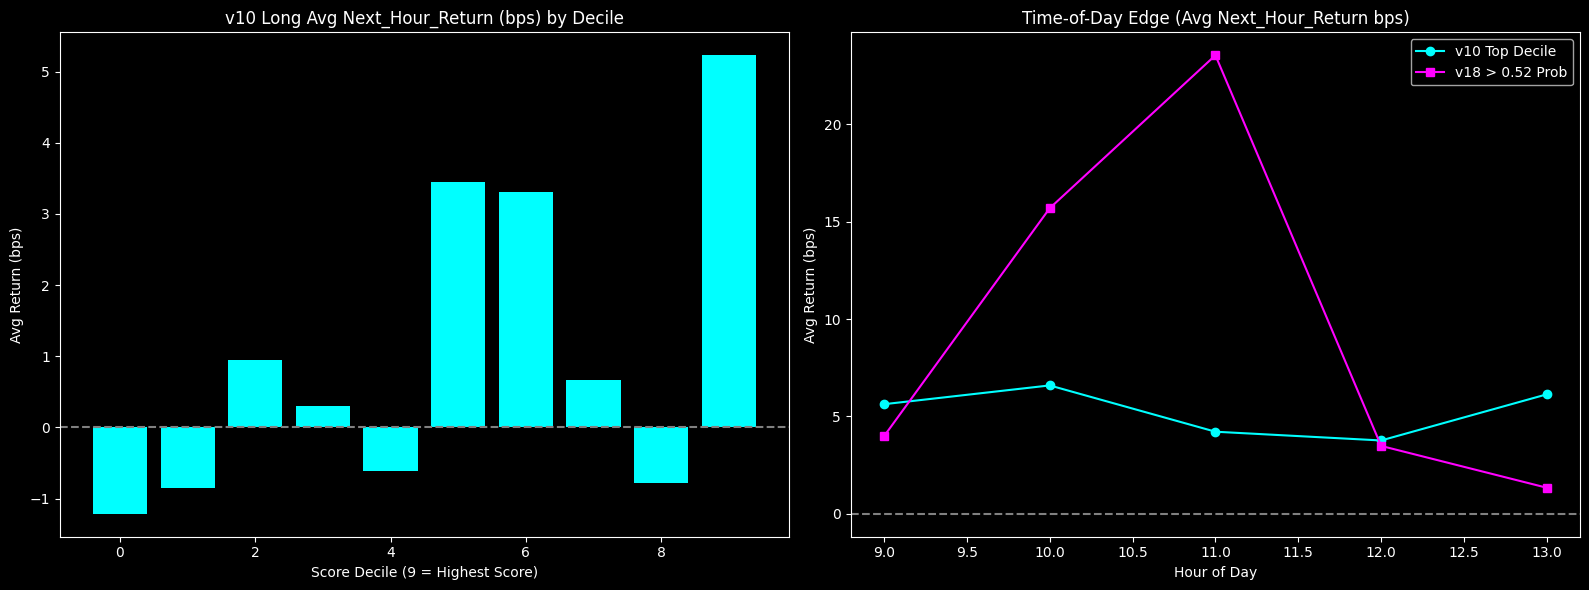

In [13]:
# Quantile / Bucket Returns for v10
df_oos['v10_long_quantile'] = pd.qcut(df_oos['v10_long_score'], q=10, labels=False, duplicates='drop')
bucket_returns = df_oos.groupby('v10_long_quantile')['Next_Hour_Return'].mean() * 10000 # in bps

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(bucket_returns.index, bucket_returns.values, color='cyan')
axes[0].set_title('v10 Long Avg Next_Hour_Return (bps) by Decile')
axes[0].set_xlabel('Score Decile (9 = Highest Score)')
axes[0].set_ylabel('Avg Return (bps)')
axes[0].axhline(0, color='gray', linestyle='--')

# ToD Edge Metrics for Top Decile vs v18 > 0.52
top_decile = df_oos[df_oos['v10_long_quantile'] == 9]
v18_pass = df_oos[df_oos['v18_long_prob'] > 0.52]

tod_v10 = top_decile.groupby('Hour')['Next_Hour_Return'].mean() * 10000
tod_v18 = v18_pass.groupby('Hour')['Next_Hour_Return'].mean() * 10000

axes[1].plot(tod_v10.index, tod_v10.values, marker='o', color='cyan', label='v10 Top Decile')
axes[1].plot(tod_v18.index, tod_v18.values, marker='s', color='magenta', label='v18 > 0.52 Prob')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Time-of-Day Edge (Avg Next_Hour_Return bps)')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg Return (bps)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{output_dir}/bucket_returns.png", dpi=150)
plt.show()

# Compute simple summary metrics
summary_metrics = {
    "v10_top_decile_bps": float(tod_v10.mean()),
    "v18_pass_bps": float(tod_v18.mean()),
    "v18_pass_count": len(v18_pass),
    "v18_win_rate": float((v18_pass['Next_Hour_Return'] > 0).mean()),
    "roc_auc": float(roc_auc)
}

with open(f"{output_dir}/summary_metrics.json", "w") as f:
    json.dump(summary_metrics, f, indent=4)